# Lab 10

In this lab, we will continue with the material from Lecture 20 and try testing different feature spaces for our $x$ matrix, as well as different delays. We will then try to see if we can improve our predictions by using an ARIMA model on the same data. Again, the dataset here is brain recordings taken from the temporal lobe during a movie watching task. 

We are going to predict the brain recordings $y$ from either the spectrogram of the sound or binary phoneme features at different time lags as our $x$ matrix.

In [7]:
import numpy as np
import sys
import os
!pip install h5py
import h5py
import scipy.io
import glob
from matplotlib import pyplot as plt
import re

from matplotlib import cm
plt.ion()

from ridge.utils import make_delayed
from ridge.ridge import cv_ridge
import logging
logging.basicConfig(level=logging.INFO) 

In [8]:
# Define a z-scoring function
zs = lambda x: (x-x.mean(0))/x.std(0)

## Get the data!

Here we will load in the data from our experiment. We have neural data `ytrain` and `ytest`, which are matrices of dimension `[time points x electrodes]`, where each electrode is taken from a session where a patient with epilepsy was listening to a set of movie clips. Here we will look at data from 3 example electrodes from one patient listening to movie clips.

In [9]:
data_file = 'MTdata_class.hf5' # Download this 

# Here we will read in the contents of the file
xtrain = {}
xtest = {}
with h5py.File(data_file, 'r') as hf:
    # This is neural data [time points x electrodes]
    ytrain = hf['ytrain'][:]
    ytest = hf['ytest'][:]
    
    # This is the spectrogram of the sounds the person heard
    xtrain['spec'] = hf['xtrain_spec'][:]
    xtest['spec'] = hf['xtest_spec'][:]
    
    # These are the phoneme features for the words the person heard
    xtrain['phn'] = hf['xtrain_phn'][:]
    xtest['phn'] = hf['xtest_phn'][:]

    # Sampling rate of the data
    fs = hf.attrs['fs']

In [10]:
print(ytrain.shape, ytest.shape)

# Show whether the data have been z-scored
print(ytrain.mean(), ytrain.std())
print(ytest.mean(), ytest.std())
print(xtrain['spec'].mean(), xtrain['spec'].std())
print(xtest['spec'].mean(), xtest['spec'].std())

(161034, 3) (13563, 3)
6.353823040442045e-18 0.999999999999996
1.6764261258072112e-17 1.0000000000000016
2.207176928182001e-15 0.9999999999999992
-1.2824659862425165e-15 0.9999999999999991


13563 time points, 80 spec features
13563 time points, 14 phn features


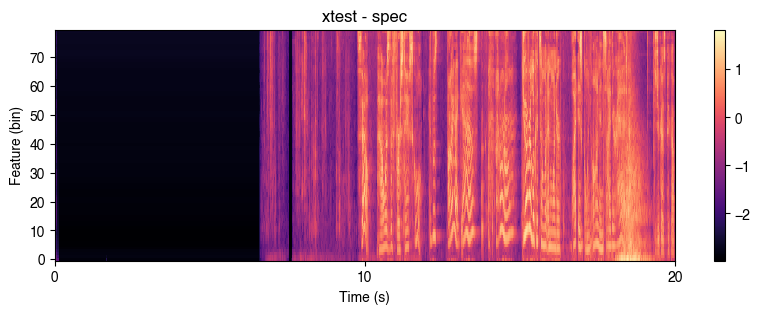

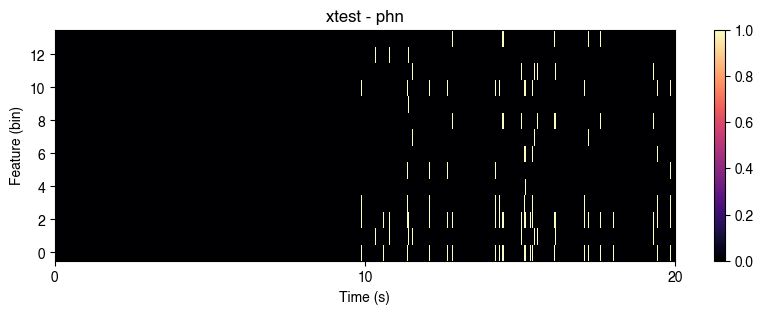

In [11]:
# Let's look at what we're using for our xtrain matrices

stim_types = ['spec', 'phn']

for stim_type in stim_types:
    ntimes, nfeats = xtest[stim_type].shape
    print(f'{ntimes} time points, {nfeats} {stim_type} features')
    nsec_to_show = 20
    
    plt.figure(figsize=(10,3))
    plt.imshow(xtest[stim_type].T, aspect='auto', cmap=cm.magma, interpolation='nearest')
    plt.gca().invert_yaxis()
    ticks = np.arange(0, ntimes, fs*10)
    plt.gca().set_xticks(ticks)
    plt.gca().set_xticklabels((ticks / fs).astype(int))
    plt.gca().set_xlim([0,nsec_to_show*fs])
    plt.title(f'xtest - {stim_type}')
    plt.colorbar()
    
    plt.xlabel('Time (s)')
    plt.ylabel('Feature (bin)')

13563 time points, 3 electrodes


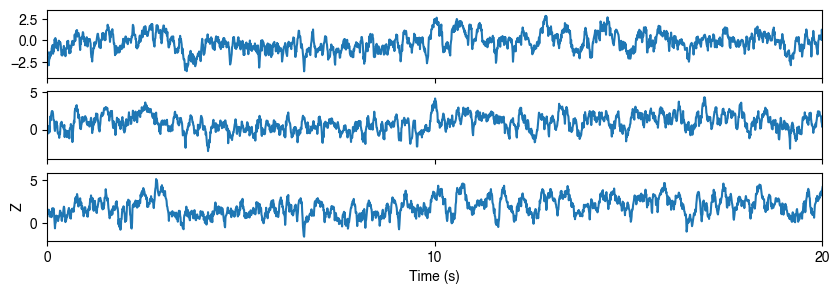

In [12]:
# Let's show the response data that goes with this test set:

ntimes,nelecs = ytest.shape
print(f'{ntimes} time points, {nelecs} electrodes')

plt.figure(figsize=(10,3))
for ch in np.arange(nelecs):
    plt.subplot(nelecs,1,ch+1)
    plt.plot(ytest[:,ch]+ch)
    ticks = np.arange(0, ntimes, fs*10)
    plt.gca().set_xticks(ticks)
    plt.gca().set_xlim([0,nsec_to_show*fs])
    #plt.colorbar(label='z-score')
    if ch == nelecs-1:
        plt.xlabel('Time (s)')
        plt.ylabel('Z')
        plt.gca().set_xticklabels((ticks / fs).astype(int))
    else:
        plt.gca().set_xticklabels([])



# How do we choose the lags?

If we want to fit a lagged regression model, we first have to choose what lags we want to consider in our model. Usually, we do this based on prior knowledge about a particular brain area (say, if we know that most responses occur within 500 milliseconds, we probably don't need to search beyond that). However, we can also use the cross-correlation function to look at where our peak lead-lag relationships lie between $x$ and $y$. We'll do that here, using a maximum possible lag between the sound features and the neural recordings of 0.6 seconds, which is reasonable based on prior literature.

In [14]:
from scipy.signal import correlate

stim_type = 'spec'  # Try changing this to 'phn' and see how the results compare

ntimes, nelecs = ytrain.shape
ntimes, nfeats = xtrain[stim_type].shape

max_lag_sec = 0.6 # seconds
max_lag = int(max_lag_sec * fs) 

lags = np.arange(-max_lag, max_lag + 1)
ccf = np.zeros((nelecs, nfeats, len(lags)))

for e in range(nelecs):
    for f in range(nfeats):
        full = correlate(ytrain[:, e], xtrain[stim_type][:, f], mode='full') / ntimes
        mid = len(full) // 2
        ccf[e, f] = full[mid - max_lag : mid + max_lag + 1]



# Plotting lag relationships

Now we will plot the average cross-correlation function across features to determine how we want to structure our lags for the regression.

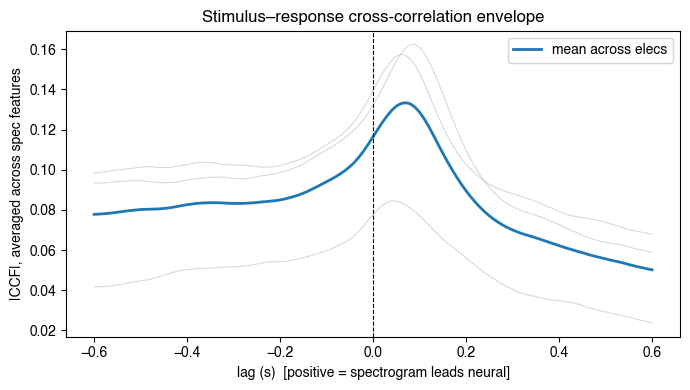

In [15]:
lags_s = lags / fs

# Average |CCF| across features, then show per-electrode traces + mean
ccf_abs = np.abs(ccf).mean(axis=1)  # [n_elec, n_lags]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lags_s, ccf_abs.T, color='gray', alpha=0.3, lw=0.8)
ax.plot(lags_s, ccf_abs.mean(0), color='C0', lw=2, label='mean across elecs')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('lag (s)  [positive = spectrogram leads neural]')
ax.set_ylabel('|CCF|, averaged across spec features')
ax.set_title('Stimulus–response cross-correlation envelope')
ax.legend()
plt.tight_layout()
plt.show()


## Create delay matrices

We now have the prerequisite matrices to perform our regression (`ytrain` and `xtrain`, and cross-validation test set `ytest` and `xtest`). To include time delays, we can set up a stacked matrix of our stimulus at different time delays. This actually has a special name -- it's called a [Toeplitz matrix](http://en.wikipedia.org/wiki/Toeplitz_matrix)). As a toy example, say we have a spectrogram with n time points and 3 frequencies.  

$$
\begin{bmatrix}
    x_{1,1} & x_{1,2} & x_{1,3} \\
    x_{2,1} & x_{2,2} & x_{2,3} \\
    x_{3,1} & x_{3,2} & x_{3,3} \\
    \vdots & \vdots & \vdots \\
    x_{n,1} & x_{n,2} & x_{n,3} \\
\end{bmatrix}
$$

Our stacked delay matrix would look something like this:

$$
\begin{bmatrix}
    x_{1,1} & x_{1,2} & x_{1,3} & 0 & 0 & 0 & 0 & 0 & 0 & \ldots & 0 & 0 & 0 \\
    x_{2,1} & x_{2,2} & x_{2,3} & x_{1,1} & x_{1,2} & x_{1,3} & 0 & 0 & 0 & \ldots & 0 & 0 & 0 \\
    x_{3,1} & x_{3,2} & x_{3,3} & x_{2,1} & x_{2,2} & x_{2,3} & x_{1,1} & x_{1,2} & x_{1,3} & \ldots & 0 & 0 & 0 \\
    x_{4,1} & x_{4,2} & x_{4,3} & x_{3,1} & x_{3,2} & x_{3,3} & x_{2,1} & x_{2,2} & x_{2,3} & \ldots & 0 & 0 & 0 \\
    \vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
    x_{n,1} & x_{n,2} & x_{n,3} & x_{n-1,1} & x_{n-1,2} & x_{n-1,3} & x_{n-2,1} & x_{n-2,2} & x_{n-2,3} & \ldots & x_{n-d+1,1} & x_{n-d+1,2} & x_{n-d+1,3} \\
\end{bmatrix}
$$


In [16]:
# Create the delayed matrices

## FILL IN 
delay_min = ... # Could have this be a negative number (in class we had this =0)
delay_max = ...  # positive number for sound leading the neural response (in class we had =0.4)

delays = np.arange(np.floor(delay_min*fs), np.ceil(delay_max*fs), dtype=int) 
print(delays)

print('Creating delayed training set matrix')
xtraind = make_delayed(xtrain[stim_type], delays)

print('Creating delayed test set matrix')
xtestd = make_delayed(xtest[stim_type], delays)

print(f'Training set is {xtrain[stim_type].shape[0]} time points by {xtraind.shape[1]} features')
print(f'Test set is {xtest[stim_type].shape[0]} time points by {xtestd.shape[1]} features')

print(f'{xtraind.shape[1]} features should be # original features {xtrain[stim_type].shape[1]} x # delays {len(delays)}')
print(xtraind.shape[1] == xtrain[stim_type].shape[1]*len(delays))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]
Creating delayed training set matrix
Creating delayed test set matrix
Training set is 161034 time points by 3200 features
Test set is 13563 time points by 3200 features
3200 features should be # original features 80 x # delays 40
True


## Look at delayed stimulus matrix

Here I'll plot only a subset of the delayed matrix so you can see its structure. Again, this is transposed so that time is on the x axis. Red lines are shown so you can appreciate the small shifts of the matrices as a function of delay.

Text(0, 0.5, 'Feature x delay')

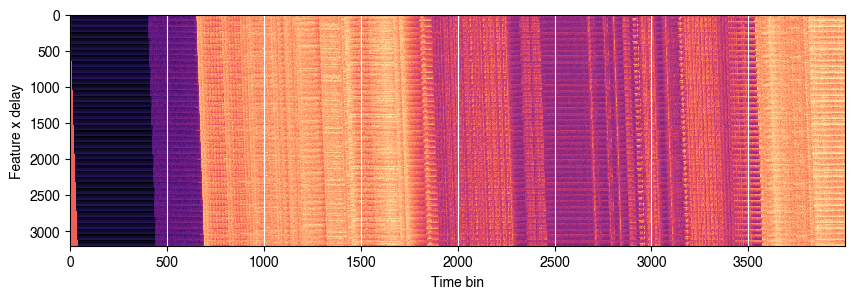

In [17]:
fig, axes = plt.subplots(figsize=(10,3))
plt.imshow(xtraind[0:4000,:].T, cmap = cm.magma, aspect='auto', interpolation='nearest')
plt.gca().xaxis.grid(color='w')
plt.xlabel('Time bin')
plt.ylabel('Feature x delay')

## Problems with OLS

In class we looked at the OLS solution and saw that the beta weights were very speckly and difficult to interpret. Here we will instead use ridge regression, which helps deal with our correlated predictors.

In [22]:
# For logging compute times, debug messages
import logging
logging.basicConfig(level=logging.DEBUG) 

# Regularization parameters (alphas - also sometimes called lambda)
alphas = np.logspace(2,8,15) # Gives you 15 values between 10^2 and 10^8
nalphas = len(alphas)

use_corr = True # Use correlation between predicted and validation set as metric for goodness of fit
single_alpha = False # If False, use best alpha for each electrode. Usually this is what you should do.
nfolds = 3 # How many folds of cross-validation we want to do to find the ridge parameter (this is a pretty low number)
chunklen = int(len(delays)*4) # We will randomize the data in chunks - we should not randomly choose 
                              # time points as that will remove correlation structure that we need to keep
nchunks = np.floor(0.2*xtraind.shape[0]/chunklen).astype('int')

nchans = ytrain.shape[1] # Number of electrodes/sensors

# outputs are:
#     beta:      the beta values, 
#     corrs:     correlations on held out data, 
#     valphas:   the best alphas for each electrode
#     allRcorrs: correlations for each alpha value across folds
#     valinds:   indices for cross validation
#     pred:      predictions
beta, corrs, valphas, allRcorrs, valinds, pred, _ = cv_ridge(xtraind, ytrain, xtestd, ytest, 
                                                               alphas, nfolds, chunklen, nchunks, 
                                                               use_corr=use_corr,  single_alpha = single_alpha, 
                                                               use_svd=False)

INFO:ridge_corr:Selecting held-out test set..
INFO:ridge_corr:Doing Eigenvalue decomposition...


Cmode = False
Number of time points is greater than the number of features
Rstim shape (not cmode): 
(128874, 3200)
Covmat shape: 
(3200, 3200)
(3200, 3200) (3200, 128874) (128874, 3)


INFO:ridge_corr:Training: alpha=100.000, mean corr=0.29080, max corr=0.34972, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268.270, mean corr=0.29263, max corr=0.35137, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719.686, mean corr=0.29606, max corr=0.35442, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=1930.698, mean corr=0.30106, max corr=0.35886, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=5179.475, mean corr=0.30668, max corr=0.36388, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=13894.955, mean corr=0.31160, max corr=0.36843, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=37275.937, mean corr=0.31507, max corr=0.37182, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=100000.000, mean corr=0.31684, max corr=0.37369, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268269.580, mean corr=0.31565, max corr=0.37254, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719685.673, mean corr=0.30725, max corr=0.36351, over-under(0.20)=3
INFO:ridge_corr

Cmode = False
Number of time points is greater than the number of features
Rstim shape (not cmode): 
(128874, 3200)
Covmat shape: 
(3200, 3200)
(3200, 3200) (3200, 128874) (128874, 3)


INFO:ridge_corr:Training: alpha=100.000, mean corr=0.27497, max corr=0.32381, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268.270, mean corr=0.27633, max corr=0.32496, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719.686, mean corr=0.27878, max corr=0.32708, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=1930.698, mean corr=0.28211, max corr=0.33012, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=5179.475, mean corr=0.28528, max corr=0.33323, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=13894.955, mean corr=0.28712, max corr=0.33527, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=37275.937, mean corr=0.28741, max corr=0.33589, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=100000.000, mean corr=0.28619, max corr=0.33501, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268269.580, mean corr=0.28205, max corr=0.33098, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719685.673, mean corr=0.27215, max corr=0.32020, over-under(0.20)=3
INFO:ridge_corr

Cmode = False
Number of time points is greater than the number of features
Rstim shape (not cmode): 
(128874, 3200)
Covmat shape: 
(3200, 3200)
(3200, 3200) (3200, 128874) (128874, 3)


INFO:ridge_corr:Training: alpha=100.000, mean corr=0.30082, max corr=0.38642, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268.270, mean corr=0.30279, max corr=0.38833, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719.686, mean corr=0.30646, max corr=0.39187, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=1930.698, mean corr=0.31182, max corr=0.39695, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=5179.475, mean corr=0.31784, max corr=0.40230, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=13894.955, mean corr=0.32316, max corr=0.40631, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=37275.937, mean corr=0.32714, max corr=0.40825, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=100000.000, mean corr=0.32954, max corr=0.40804, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=268269.580, mean corr=0.32943, max corr=0.40501, over-under(0.20)=3
INFO:ridge_corr:Training: alpha=719685.673, mean corr=0.32391, max corr=0.39665, over-under(0.20)=3
INFO:ridge_corr

Cmode = False
Number of time points is greater than the number of features
stim shape (not cmode): 
(161034, 3200)
Covmat shape: 
(3200, 3200)


INFO:ridge_corr:Computing weights
INFO:ridge_corr:Predicting responses for predictions set..


(3200, 3200) (3200, 161034) (161034, 3)


## Check alpha values

We will now check the best regularization parameter $\alpha$ for each channel. This will plot each electrode as a curve, with each correlation value vs. alpha. For most "good" electrodes there will be a peak value in the middle of the range of alphas. If your model is consistently showing that the average best $\alpha$ is the smallest or largest value, you should widen your range appropriately and re-run the model.

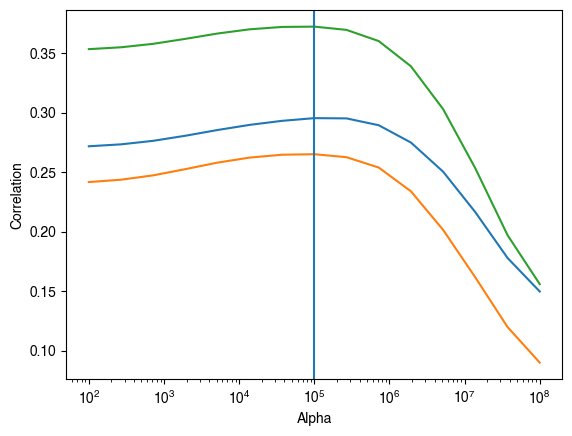

In [23]:
fig = plt.figure()
plt.semilogx(alphas, allRcorrs.mean(2))  # Log space alphas
# Plot a line at the maximum alpha. This should be in the middle
plt.axvline(alphas[allRcorrs.mean(2).mean(1).argmax()])
plt.xlabel('Alpha')
plt.ylabel('Correlation')
plt.show()

## Show predictions

Now we will show the predicted versus actual activity for all electrodes. If these are well-modeled by the STRF, you should see that the predicted and actual activity look fairly similar. If a larger regularization value alpha was chosen, the predicted activity will tend to look smoother.

Prediction matrix shape:  (13563, 3)
Response matrix shape:  (13563, 3)


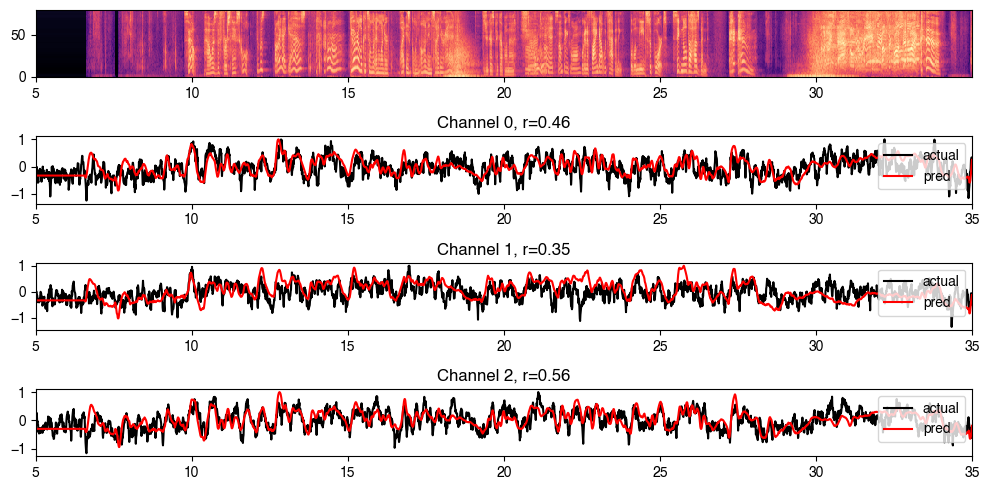

In [24]:
# How much time to show?
ntimes = int(30*fs) # Show 30 seconds of time
ntimes_start = int(5*fs)  # Start 5 seconds in since there is a lot of silence at the beginning
times = np.arange(ntimes_start, ntimes_start+ntimes)/fs

# Plot predictions vs. actual response
print("Prediction matrix shape: ", pred.shape)
print("Response matrix shape: ", ytest.shape)

fig = plt.figure(figsize=(10,5))
plt.subplot(nelecs+1,1,1)
plt.imshow(xtestd[ntimes_start:ntimes_start+ntimes,:nfeats].T, aspect='auto', cmap=cm.magma, interpolation='nearest')
xticks = np.arange(0, len(times), step=500)
plt.gca().set_xticks(xticks)
plt.gca().set_xticklabels([int(times[x]) for x in xticks])
plt.gca().invert_yaxis()

# Loop through the best channels
for i in np.arange(nelecs):
    # Get the predicted neural response 
    prediction = pred[ntimes_start:ntimes_start+ntimes, i]
    prediction = prediction/prediction.max() # Rescale to max
    
    actual_resp = ytest[ntimes_start:ntimes_start+ntimes,i]
    actual_resp = actual_resp/actual_resp.max(0) # Rescale to max
    
    plt.subplot(nelecs+1,1,i+2)
    plt.plot(times, actual_resp, color='k', label='actual')
    plt.plot(times, prediction.T, color='r',label='pred')
    
    plt.title(f'Channel {i}, r={corrs[i]:.2f}')
    plt.gca().set_xlim([ntimes_start/fs,(ntimes_start+ntimes)/fs])
    plt.legend(loc='upper right')
plt.tight_layout()


## Visualizing the STRF filters

Here we will show the STRF filters we've derived for each channel.  These filters show which spectrotemporal features of the stimulus best predict an increase or decrease in the observed neural activity.

(3200, 3)


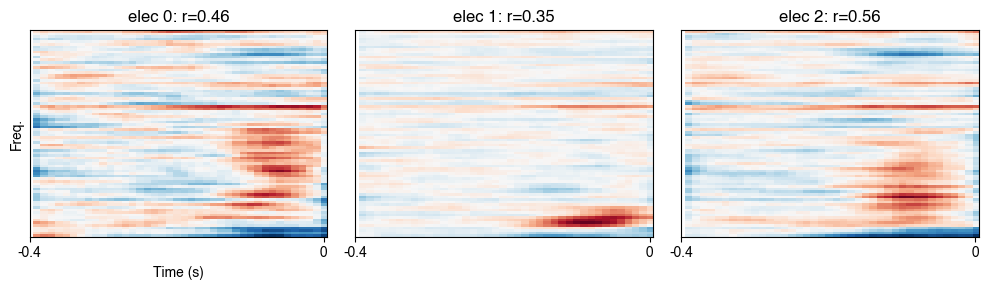

In [26]:
# Plot all of the STRFs, using a separate regularization parameter for each (whichever gives the best performance)

fig = plt.figure(figsize=(10,3))
print(beta.shape)

for c in np.arange(nelecs):
    ax = fig.add_subplot(1,nelecs,c+1)
    strf = beta[:,c].reshape(len(delays),-1)
    smax = np.abs(strf).max()
    plt.imshow(strf.T, vmin=-smax, vmax=smax, cmap = cm.RdBu_r, aspect='auto', interpolation='nearest')
    plt.title(f'elec {c}: r={corrs[c]:.2f}')
    if c==0:
        plt.xlabel('Time (s)')
        plt.ylabel('Freq.')
    ax.set_ylim(ax.get_ylim()[::-1]) # This just reverses the y axis so low frequency is at the bottom
    ax.xaxis.set_ticks([0,len(delays)])
    ax.xaxis.set_ticklabels([0, -len(delays)/fs])
    plt.gca().invert_xaxis() # Invert the x-axis so Time (s) is on the x rather than Time delay (s)

    ax.yaxis.set_ticks([])
    #title('alpha=%3.3g'%(alphas[best_alphas_indiv[c]]))
    #colorbar()

plt.tight_layout();

## How does the selection of regularization parameter $\alpha$ affect the observed coefficients?

It is important to choose a range of $\alpha$ values and determine which yield the best predictions on held out data, since the regularization parameter itself can affect the structure of your STRF.

One of the things we did above was just to choose the best regularization parameter for each electrode separately. However, this choice does affect what the STRF filters look like, so here we will do an exercise where we fit all possible alphas and show the weights. This is just for educational purposes and is not typically needed in an analysis.

In [27]:
from ridge.ridge import eigridge

# Get weights for all alphas 
all_alpha_wts = []
for alpha in alphas:
    print("Fitting model for alpha=%.3g"%(alpha))
    tmp_wt = eigridge(xtraind, ytrain, alpha)
    all_alpha_wts.append(tmp_wt)

awt=np.array(all_alpha_wts)

INFO:ridge_corr:Doing Eigenvalue decomposition on the full stimulus matrix...


Fitting model for alpha=100
Cmode = False
Number of time points is greater than the number of features
stim shape (not cmode): 
(161034, 3200)
Covmat shape: 
(3200, 3200)


INFO:ridge_corr:Computing weights
INFO:ridge_corr:Doing Eigenvalue decomposition on the full stimulus matrix...


(3200, 3200) (3200, 161034) (161034, 3)
Fitting model for alpha=268
Cmode = False
Number of time points is greater than the number of features
stim shape (not cmode): 
(161034, 3200)
Covmat shape: 
(3200, 3200)


INFO:ridge_corr:Computing weights
INFO:ridge_corr:Doing Eigenvalue decomposition on the full stimulus matrix...


...

(3200, 3200) (3200, 161034) (161034, 3)
Fitting model for alpha=3.73e+07
Cmode = False
Number of time points is greater than the number of features
stim shape (not cmode): 
(161034, 3200)
Covmat shape: 
(3200, 3200)


INFO:ridge_corr:Computing weights
INFO:ridge_corr:Doing Eigenvalue decomposition on the full stimulus matrix...


(3200, 3200) (3200, 161034) (161034, 3)
Fitting model for alpha=1e+08
Cmode = False
Number of time points is greater than the number of features
stim shape (not cmode): 
(161034, 3200)
Covmat shape: 
(3200, 3200)


INFO:ridge_corr:Computing weights


(3200, 3200) (3200, 161034) (161034, 3)


## Calculating performance on the validation set for each alpha

Next, we need to calculate the predicted response to our validation set for our assessment of model performance.  Normally we would only do this for the best alpha found in the previous step, but here we will calculate all STRFs for all channels and all alphas so we can compare the correlations later.

The predictions are normally returned by `cv_ridge`, but here we can also calculate them directly by getting the dot product between the delayed stimulus matrix and the STRF weights. This is exactly calculating $\hat{Y} = X \beta$.

In [32]:
print("Calculating predicted response to validation set")
wt_array = np.dstack(awt)
print(wt_array.shape)
vPred_alpha = [ [ np.dot(xtestd, wt_array[:,ch,alph]) for ch in np.arange(nchans)] for alph in np.arange(nalphas)]
vPred_alpha = np.array(vPred_alpha)

Calculating predicted response to validation set
(3200, 3, 15)


## Get model performance for each alpha value

Since we didn't get them for free, we will now also manually calculate the correlations between each prediction and the actual held out data `vResp`.

In [33]:
print("Calculating correlations on validation set")
vcorr  = [ [ np.corrcoef(vPred_alpha[alph][ch], ytest[:,ch])[0,1] for ch in np.arange(nchans)] for alph in np.arange(nalphas)]
vcorr = np.array(vcorr)
print("Done calculating correlations")
print("Correlation matrix shape: ", vcorr.shape)

Calculating correlations on validation set
Done calculating correlations
Correlation matrix shape:  (15, 3)


## How does the choice of $\alpha$ affect the STRF structure?

Here we will plot the STRF arrays for the 5 best channels for each alpha regularization value. Each row is an electrode, each column is an alpha value. You will see that as the alpha value increases, the STRF weights become broader and smoother. The r-value should peak somewhere in the middle of the range.

Here we will indicate the best weight matrix and alphas with red titles. These are the weights and correlations returned by `bootstrap_ridge`.

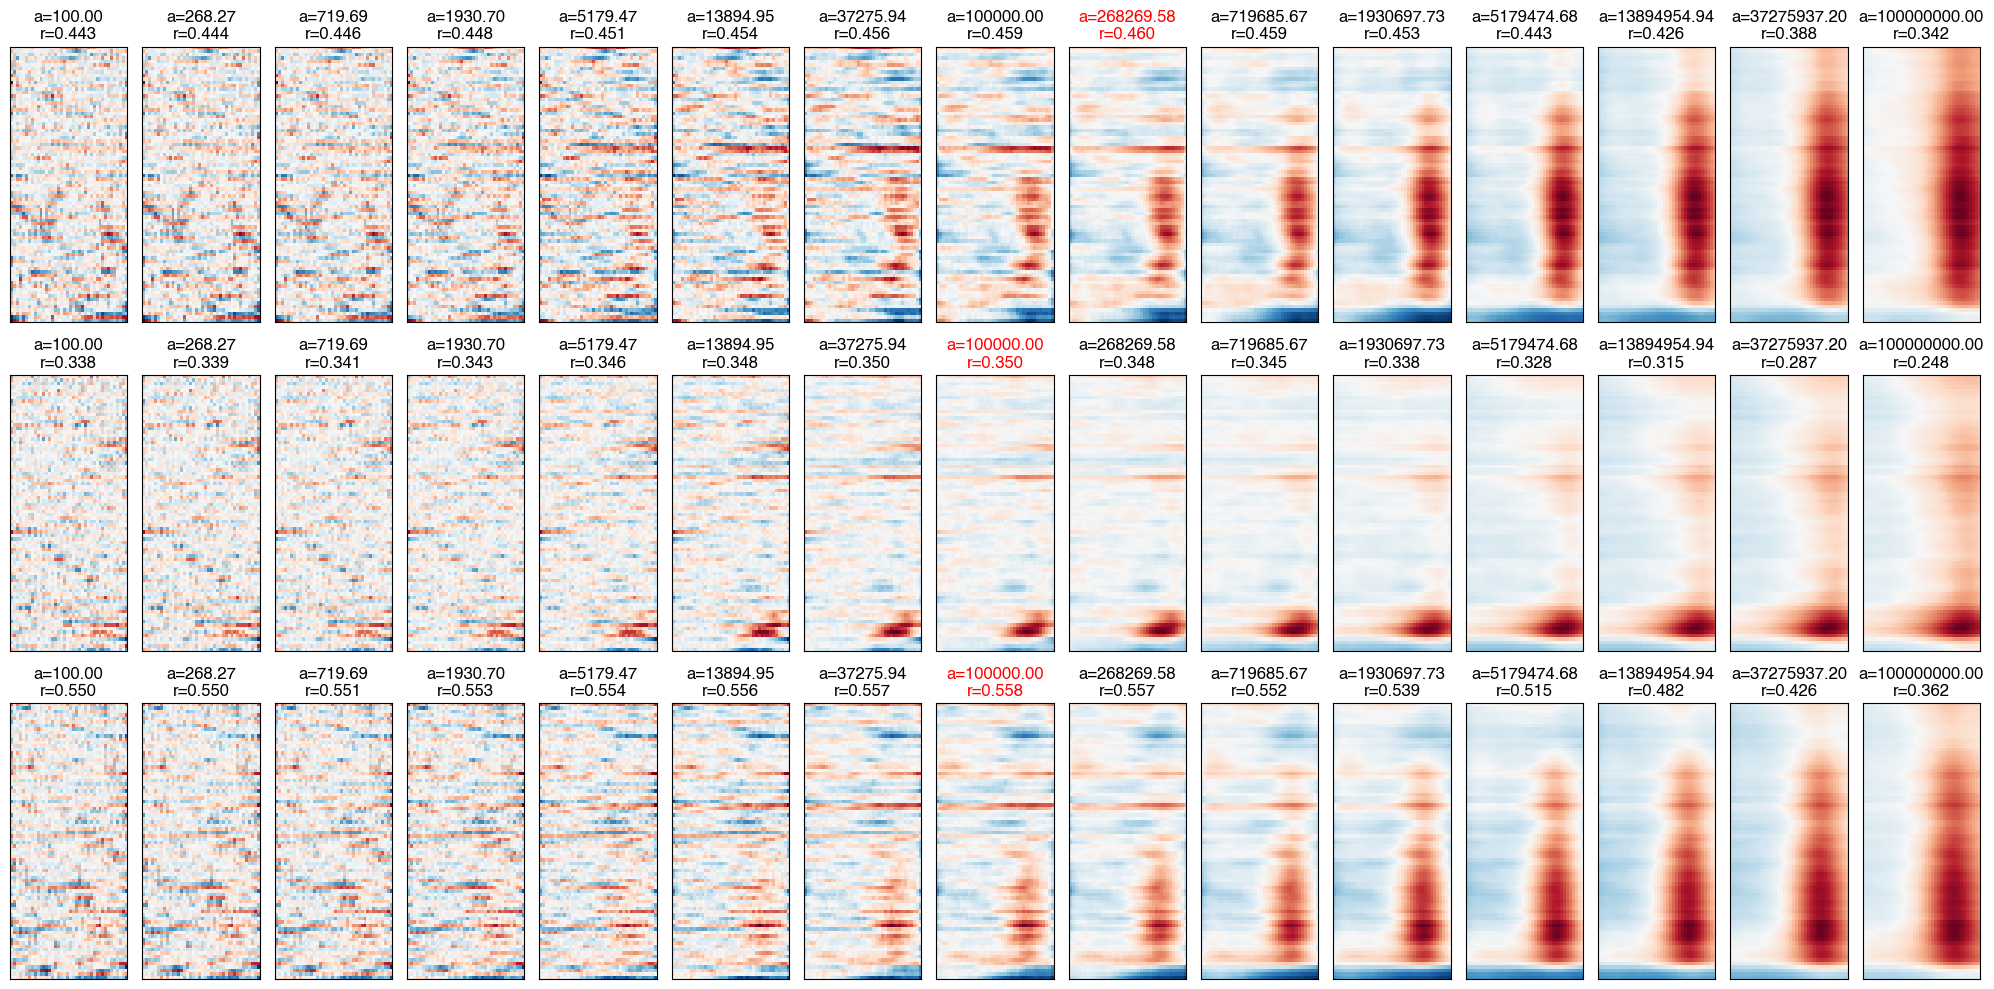

In [34]:
# Show how regularization parameter changes STRFs
fig = plt.figure(figsize=(20,10))
fig.clf()
axes = [fig.add_subplot(nelecs,len(alphas),ii+1) for ii in range((len(alphas))*nelecs)]
p = 0
for ch in np.arange(nelecs): # loop through all electrodes
    for a in np.arange(len(alphas)): # loop through the alpha regularization parameter
        strf = wt_array[:,ch,a].reshape(len(delays),-1)
        smax = np.abs(strf).max()
        axes[p].imshow(strf.T,vmin=-smax, vmax=smax, cmap = cm.RdBu_r, aspect='auto', interpolation='nearest')
        axes[p].xaxis.set_ticks([])
        axes[p].yaxis.set_ticks([])
        axes[p].set_ylim(axes[p].get_ylim()[::-1]) # This just reverses the y axis so low frequency is at the bottom
        axes[p].set_xlim(axes[p].get_xlim()[::-1]) # Invert the x-axis so Time (s) is on the x rather than Time delay (s)
        axes[p].set_title(f'a={alphas[a]:.2f}\nr={vcorr[a,ch]:.3f}')
        if a == vcorr[:,ch].argmax():
            axes[p].set_title(f'a={alphas[a]:.2f}\nr={vcorr[a,ch]:.3f}', color='r')
        p+=1

plt.tight_layout()
#fig.subplots_adjust(hspace=.5, wspace=.8)
        

# Putting it together

Here you've now seen a real-world example of a time-lagged regression that incorporates all of the following topics we've discussed so far in class:

1. Spectral analysis (using the spectrogram of the sound as a covariate in regression)
2. Multiple linear regression with time lags
3. Cross-validation
4. Dealing with auto-correlated predictors
5. OLS vs. ridge

# For you to try

* Try using different lags (shorter? longer? positive and negative? negative only?)
* Try using 'phn' instead of 'spec' in the training - how does the model performance compare (when assessed as correlation)?